### Implementation of Convergent Cross Mapping

Author: Phoebe Kuang

Date: Apr 20, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 1.5

#### Introduction

This notebook implements Convergent Cross Mapping (CCM) to distinguish causality from correlation in non-linear deterministic dynamical systems. 

We will validate the algorithm on a continuous chaotic system (the Lorenz Attractor) and a discrete biological model (a 2-species logistic map). Then, we will demonstrate a structural failure case caused by symmetry.

---

#### System 1 - The Lorenz System & Numerical Convergence

To guarantee our numerical solver is accurate, we integrate the Lorenz system up to $t = 1.4$ (approximately one Lyapunov time) using three different maximum step sizes ($dt$). We expect the trajectories to overlap, proving numerical convergence. We then generate a longer trajectory as our main manifold and visualize it to see the classic butterfly" attractor.

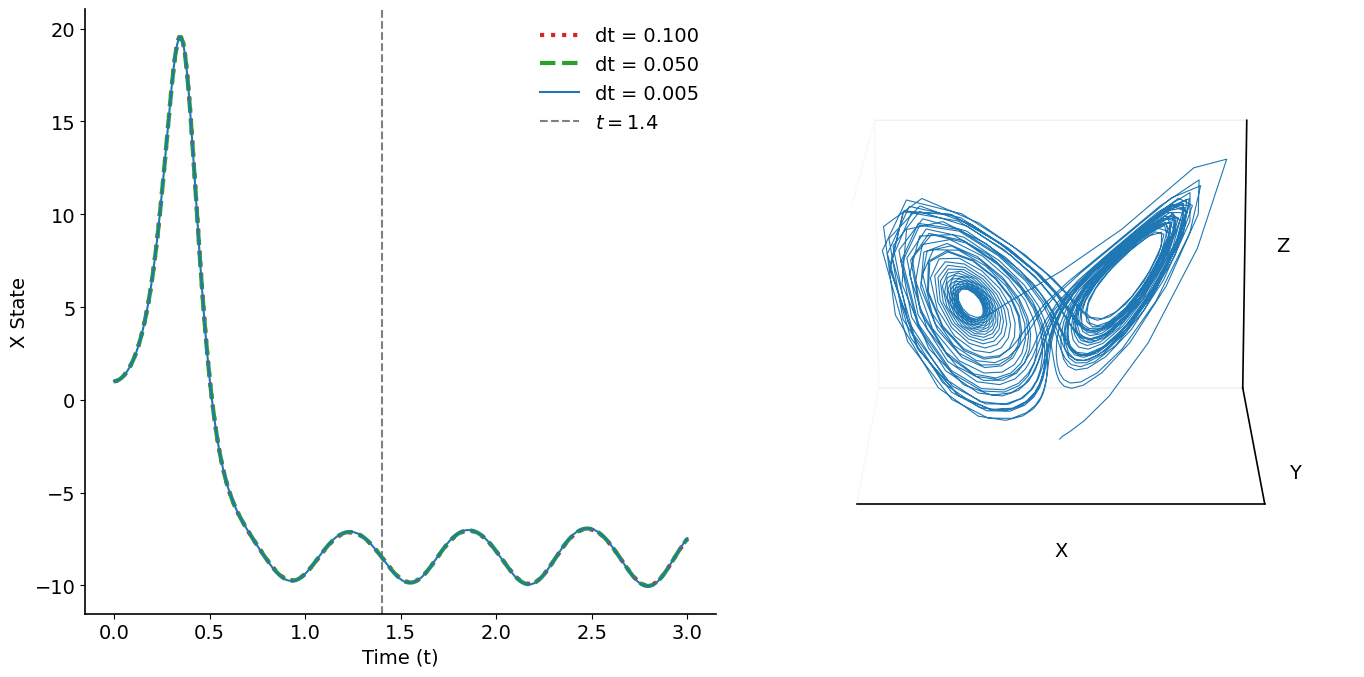

In [2]:
# LORENZ SYSTEM 

# Here our default parameters are set to the most classic chaotic regime. 
# The function returns the derivatives for the Lorenz system, 
# which will be used in the RK45 ODE solver to generate the trajectories.

def lorenz_deriv(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """Derivatives for the classic Lorenz system."""
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

initial_state = [1.0, 1.0, 1.0]
t_val_span = (0, 3)
t_val_eval = np.linspace(0, 3, 300) 

# 1. Numerical Convergence Test (Testing different max step sizes)
sol_dt_large = solve_ivp(lorenz_deriv, t_val_span, initial_state, method='RK45', max_step=0.1, t_eval=t_val_eval)
sol_dt_med   = solve_ivp(lorenz_deriv, t_val_span, initial_state, method='RK45', max_step=0.05, t_eval=t_val_eval)
sol_dt_small = solve_ivp(lorenz_deriv, t_val_span, initial_state, method='RK45', max_step=0.005, t_eval=t_val_eval)

# 2. Generate Main Manifold for CCM testing
t_main_span = (0, 100.0)
dt = 0.05  
t_main_eval = np.arange(0, 100.0, dt)
sol_main = solve_ivp(lorenz_deriv, t_main_span, initial_state, method='RK45', max_step=dt, t_eval=t_main_eval)

L_X, L_Y, L_Z = sol_main.y

# 3. Plotting
fig = plt.figure(figsize=(14, 7))

# Left Plot: Numerical Convergence
ax1 = fig.add_subplot(121)
ax1.plot(sol_dt_large.t, sol_dt_large.y[0], label='dt = 0.100', color='#d62728', linestyle=':', lw=3)
ax1.plot(sol_dt_med.t, sol_dt_med.y[0], label='dt = 0.050', color='#2ca02c', linestyle='--', lw=3)
ax1.plot(sol_dt_small.t, sol_dt_small.y[0], label='dt = 0.005', color='#1f77b4', linestyle='-', lw=1.5)
ax1.axvline(t_main_eval[28], color='gray', linestyle='--', label='$t = 1.4$', zorder=0)
ax1.set_xlabel("Time (t)")
ax1.set_ylabel("X State")
ax1.legend(frameon=False)

# Right Plot: 3D Lorenz Attractor
ax2 = fig.add_subplot(122, projection='3d')
ax2.view_init(elev=15, azim=-90)
ax2.plot(L_X[:1000], L_Y[:1000], L_Z[:1000], lw=0.8, color='#1f77b4')
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
ax2.xaxis.pane.fill = False; ax2.yaxis.pane.fill = False; ax2.zaxis.pane.fill = False
ax2.grid(False)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

plt.tight_layout()
plt.show()

####  System 2 - Asymmetric Coupled System

Here we implement the 2-species logistic map from Sugihara et al. (2012). To explicitly test unidirectional causality, we set the coupling coefficient $\beta_{x,y} = 0$ (meaning $Y$ does not affect $X$) and $\beta_{y,x} = 0.2$ (meaning $X$ affects $Y$). This mathematically guarantees $X \Rightarrow Y$.

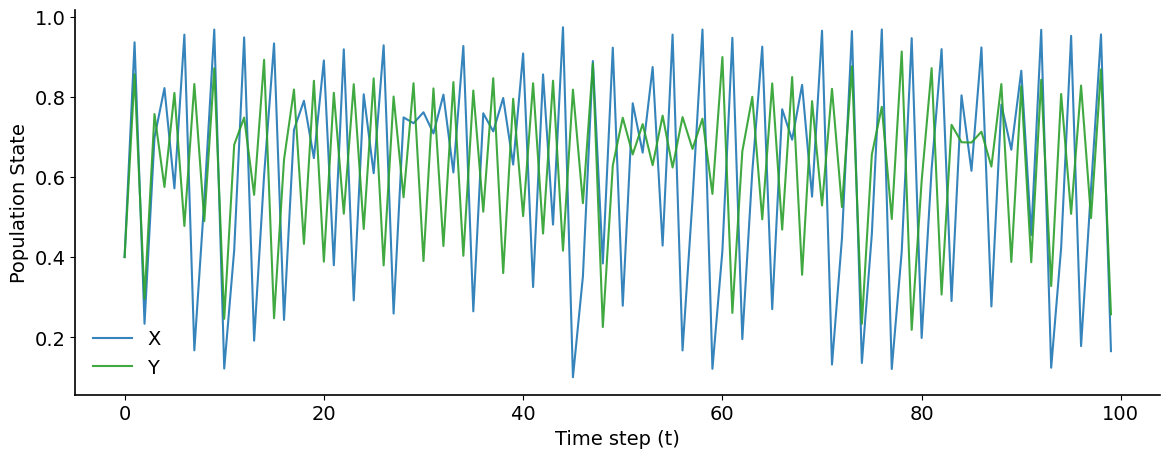

In [3]:
# ASYMMETRIC COUPLED SYSTEM

# We generate a 2-species logistic map with strict unidirectional coupling.

def generate_asymmetric_logistic(N=1000):
    X = np.zeros(N)
    Y = np.zeros(N)
    
    # Set initial conditions
    np.random.seed(25)  # For reproducibility
    X[0] = 0.4
    Y[0] = 0.4
    
    # Parameters
    rx, ry = 3.9, 3.7
    beta_xy = 0.0  # Y does NOT affect X
    beta_yx = 0.2  # X DOES affect Y
    
    for t in range(N - 1):
        X[t+1] = X[t] * (rx - rx * X[t] - beta_xy * Y[t])
        Y[t+1] = Y[t] * (ry - ry * Y[t] - beta_yx * X[t])
        
    return X, Y

A_X, A_Y = generate_asymmetric_logistic(N=1000)

# Plotting the first 100 time steps
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(A_X[:100], label='X', color='#1f77b4', alpha=0.9, lw=1.5)
ax.plot(A_Y[:100], label='Y', color='#2ca02c', alpha=0.9, lw=1.5)

ax.set_xlabel("Time step (t)")
ax.set_ylabel("Population State")
ax.legend(frameon=False)

# plt.tight_layout()
plt.show()

---

#### Implementation of Convergent Cross Mapping (CCM)

We implement the CCM algorithm following the exact distance-weighting equations from Sugihara et al. (2012). 

We modularize the logic into multiple steps: 

1. Reconstructing the time-delay shadow manifold.
2. Locating the $E+1$ nearest neighbors in state space.
3. Computing the exponential weights based on spatial distance.
4. Generating the cross-mapped predictions and calculating the Pearson correlation skill ($\rho$).

In [4]:
# CCM ALGORITHM

def build_shadow_manifold(series, E, tau):
    """
    Constructs the time-delay embedding manifold from a 1D time series.
    Returns the manifold matrix and the valid time indices.
    """
    N = len(series)
    # Identify indices that have enough history to be embedded
    valid_idx = np.arange((E - 1) * tau, N)
    manifold = np.zeros((len(valid_idx), E))
    
    for i in range(E):
        manifold[:, i] = series[valid_idx - i * tau]
        
    return manifold, valid_idx

def nearest_neighbors(dist_vector, E):
    """
    Finds the indices and distances of the E+1 nearest historical neighbors.
    """
    # argsort sorts distances; index 0 is the point itself (dist=0), so we skip it
    sorted_indices = np.argsort(dist_vector)
    neighbor_indices = sorted_indices[1 : E + 2] 
    neighbor_dists = dist_vector[neighbor_indices]
    
    return neighbor_indices, neighbor_dists

def compute_weights(neighbor_dists):
    """
    Computes exponential weights based on the distance to the closest neighbor.
    """
    # Add a tiny epsilon to the closest distance to prevent division by zero
    min_dist = max(neighbor_dists[0], 1e-6) 
    weights = np.exp(-neighbor_dists / min_dist)
    
    # Normalize weights so they sum to 1
    return weights / np.sum(weights)

def ccm(X, Y, E, tau, L):
    """
    Executes a single run of CCM. 
    Tests if X => Y by checking if M_Y can accurately predict X.
    """
    # 1. Restrict data to the current library length L
    lib_X = X[:L]
    lib_Y = Y[:L]
    
    # 2. Build the shadow manifold from the affected variable (M_Y)
    M_Y, valid_idx = build_shadow_manifold(lib_Y, E, tau)
    
    # If the library is too short to find E+1 neighbors, prediction is impossible
    if len(valid_idx) < E + 2: 
        return 0.0
        
    true_X = lib_X[valid_idx]
    pred_X = np.zeros(len(valid_idx))
    
    dist_matrix = cdist(M_Y, M_Y, metric='euclidean')
    
    # 3. Cross-map loop
    for i in range(len(valid_idx)):
        n_idx, n_dists = nearest_neighbors(dist_matrix[i], E)
        weights = compute_weights(n_dists)
        pred_X[i] = np.sum(weights * true_X[n_idx])
        
    # 4. Calculate prediction skill (Pearson correlation coefficient)
    # If the prediction is completely flat, correlation is undefined/zero
    if np.std(pred_X) == 0: 
        return 0.0
        
    rho, _ = pearsonr(true_X, pred_X)
    
    # CCM defines negative correlations as having zero predictive skill
    return max(0.0, rho)

def test_convergence(X, Y, E, tau, L_range):
    """
    Evaluates CCM over a sequence of library lengths to generate a convergence curve.
    """
    return [ccm(X, Y, E, tau, L) for L in L_range]

---

#### Success Cases & Visualize Manifold Embeddings

We evaluate CCM on our ground-truth systems by plotting prediction skill ($\rho$) against library length ($L$). 
* For the **Lorenz System** (bidirectionally coupled), we expect both $\hat{X}|M_Y$ and $\hat{Y}|M_X$ to converge. 
* For the **Asymmetric Logistic Map** ($X \Rightarrow Y$), we expect asymmetry: $\hat{X}|M_Y$ should converge, while $\hat{Y}|M_X$ should remain low.

To understand this geometrically, we also visualize the shadow manifolds. For the two systems, we highlight a contemporaneous target state ($t^*$) and its $E+1$ nearest neighbors on $M_X$ and their corresponding states on $M_Y$.

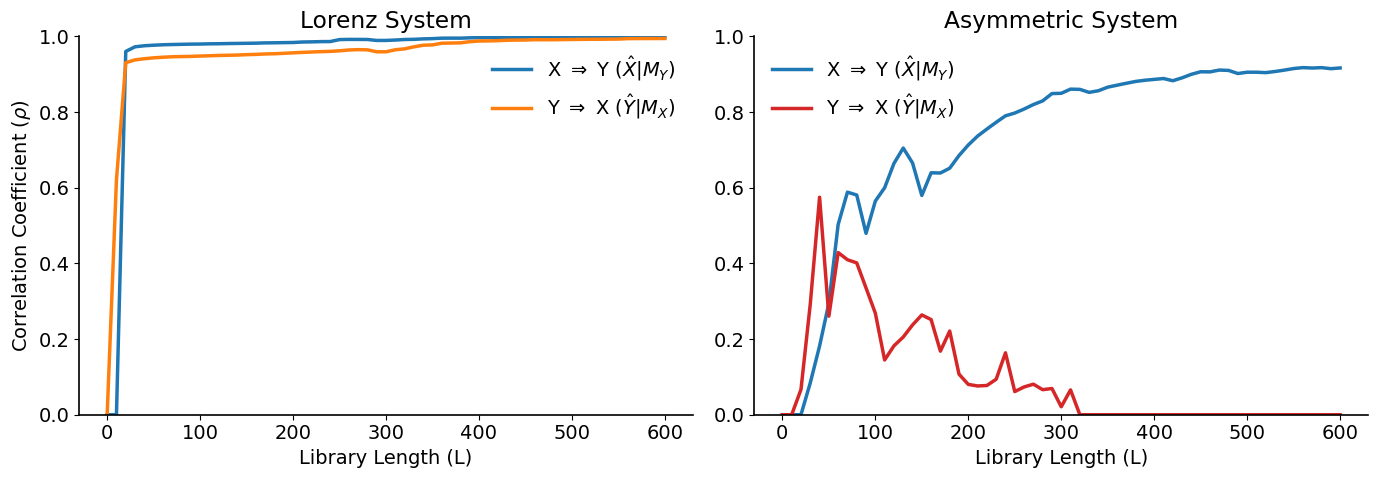

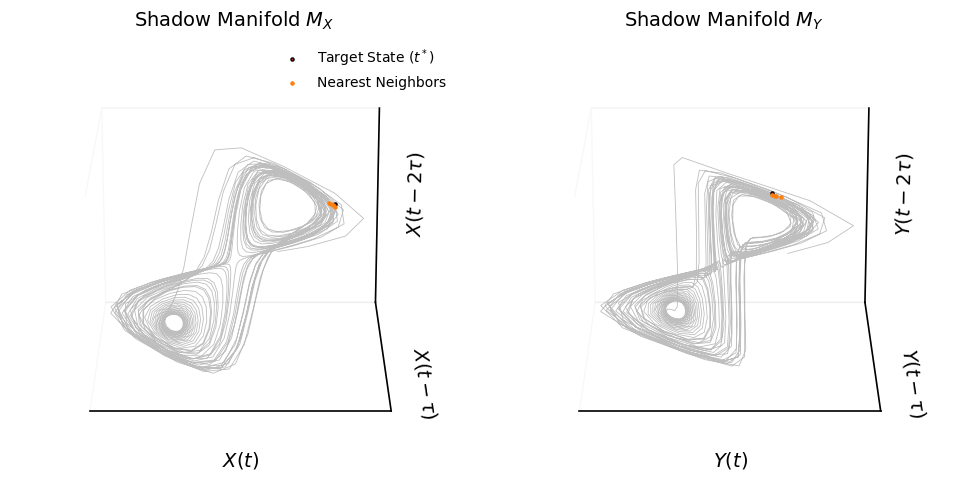

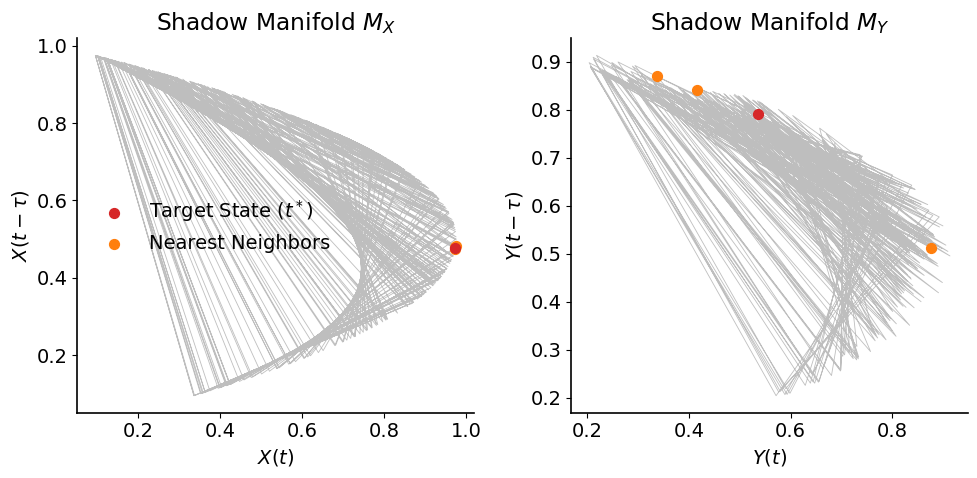

In [5]:
L_range = np.arange(0, 601, 10)

# 1. Calculate Convergence Curves
rho_XY_lor = test_convergence(L_X, L_Y, E=3, tau=2, L_range=L_range)
rho_YX_lor = test_convergence(L_Y, L_X, E=3, tau=2, L_range=L_range)

rho_XY_asy = test_convergence(A_X, A_Y, E=2, tau=1, L_range=L_range)
rho_YX_asy = test_convergence(A_Y, A_X, E=2, tau=1, L_range=L_range)

# Plot Convergence
fig_conv, (ax_c1, ax_c2) = plt.subplots(1, 2, figsize=(14, 5))
ax_c1.plot(L_range, rho_XY_lor, label=r'X $\Rightarrow$ Y ($\hat{X}|M_Y$)', color='#1f77b4', lw=2.5)
ax_c1.plot(L_range, rho_YX_lor, label=r'Y $\Rightarrow$ X ($\hat{Y}|M_X$)', color='#ff7f0e', lw=2.5)
ax_c1.set_xlabel("Library Length (L)"); ax_c1.set_ylabel(r"Correlation Coefficient ($\rho$)")
ax_c1.set_title("Lorenz System")
ax_c1.set_ylim(0, 1)
ax_c1.legend(frameon=False)
ax_c2.plot(L_range, rho_XY_asy, label=r'X $\Rightarrow$ Y ($\hat{X}|M_Y$)', color='#1f77b4', lw=2.5)
ax_c2.plot(L_range, rho_YX_asy, label=r'Y $\Rightarrow$ X ($\hat{Y}|M_X$)', color='#d62728', lw=2.5)
ax_c2.set_xlabel("Library Length (L)")
# ax_c2.set_ylabel(r"Correlation Coefficient ($\rho$)")
ax_c2.set_title("Asymmetric System")
ax_c2.set_ylim(0, 1)
ax_c2.legend(frameon=False)
plt.tight_layout()
plt.show()

# 3. Visualize Manifolds Embeddings: LORENZ
E_lor, tau_lor = 3, 2
M_X_lor, valid_X_lor = build_shadow_manifold(L_X[:1000], E_lor, tau_lor)
M_Y_lor, valid_Y_lor = build_shadow_manifold(L_Y[:1000], E_lor, tau_lor)

t_star_lor = 350
dist_mat_X = cdist(M_X_lor, M_X_lor)
n_idx_lor, _ = nearest_neighbors(dist_mat_X[t_star_lor], E_lor)

fig_lor = plt.figure(figsize=(10, 5))
ax_l1 = fig_lor.add_subplot(121, projection='3d')
ax_l1.plot(M_X_lor[:, 0], M_X_lor[:, 1], M_X_lor[:, 2], color='#7f7f7f', alpha=0.5, lw=0.6)
ax_l1.scatter(*M_X_lor[t_star_lor], color='#d62728', s=5, edgecolor='black', zorder=5, label=r'Target State ($t^*$)')
for n in n_idx_lor: ax_l1.scatter(*M_X_lor[n], color='#ff7f0e', s=5, zorder=4, label='Nearest Neighbors' if n==n_idx_lor[0] else "")
ax_l1.set_xlabel(r'$X(t)$', fontsize=14); ax_l1.set_ylabel(r'$X(t-\tau)$', fontsize=14); ax_l1.set_zlabel(r'$X(t-2\tau)$', fontsize=14)
ax_l1.set_title("Shadow Manifold $M_X$", fontsize=14)
ax_l1.view_init(elev=20, azim=-90)
ax_l1.legend(frameon=False, fontsize=10)

ax_l2 = fig_lor.add_subplot(122, projection='3d')
ax_l2.plot(M_Y_lor[:, 0], M_Y_lor[:, 1], M_Y_lor[:, 2], color='#7f7f7f', alpha=0.5, lw=0.6)
ax_l2.scatter(*M_Y_lor[t_star_lor], color='#d62728', s=5, edgecolor='black', zorder=5)
for n in n_idx_lor: ax_l2.scatter(*M_Y_lor[n], color='#ff7f0e', s=5, zorder=4)
ax_l2.set_xlabel(r'$Y(t)$', fontsize=14); ax_l2.set_ylabel(r'$Y(t-\tau)$', fontsize=14); ax_l2.set_zlabel(r'$Y(t-2\tau)$', fontsize=14)
ax_l2.set_title("Shadow Manifold $M_Y$", fontsize=14)
ax_l2.view_init(elev=20, azim=-90)

# Clean 3D panes
for ax in [ax_l1, ax_l2]:
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.tight_layout()
plt.show()

# Visualize Manifolds Embeddings: LOGISTIC
E_asy, tau_asy = 2, 1
M_X_asy, _ = build_shadow_manifold(A_X[:300], E_asy, tau_asy)
M_Y_asy, _ = build_shadow_manifold(A_Y[:300], E_asy, tau_asy)

t_star_asy = 150
dist_mat_X_asy = cdist(M_X_asy, M_X_asy)
n_idx_asy, _ = nearest_neighbors(dist_mat_X_asy[t_star_asy], E_asy)

fig_asy, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(10, 5))
ax_a1.plot(M_X_asy[:, 0], M_X_asy[:, 1], color='#7f7f7f', alpha=0.5, lw=0.6)
ax_a1.scatter(*M_X_asy[t_star_asy], color='#d62728', s=50, label=r'Target State ($t^*$)', zorder=5)
for n in n_idx_asy: ax_a1.scatter(*M_X_asy[n], color='#ff7f0e', s=50, label='Nearest Neighbors' if n==n_idx_asy[0] else "", zorder=4)
ax_a1.set_xlabel(r'$X(t)$'); ax_a1.set_ylabel(r'$X(t-\tau)$')
ax_a1.set_title("Shadow Manifold $M_X$")
ax_a1.legend(frameon=False)

ax_a2.plot(M_Y_asy[:, 0], M_Y_asy[:, 1], color='#7f7f7f', alpha=0.5, lw=0.6)
ax_a2.scatter(*M_Y_asy[t_star_asy], color='#d62728', s=50, zorder=5)
for n in n_idx_asy: ax_a2.scatter(*M_Y_asy[n], color='#ff7f0e', s=50, zorder=4)
ax_a2.set_xlabel(r'$Y(t)$'); ax_a2.set_ylabel(r'$Y(t-\tau)$')
ax_a2.set_title("Shadow Manifold $M_Y$")

plt.tight_layout()
plt.show()

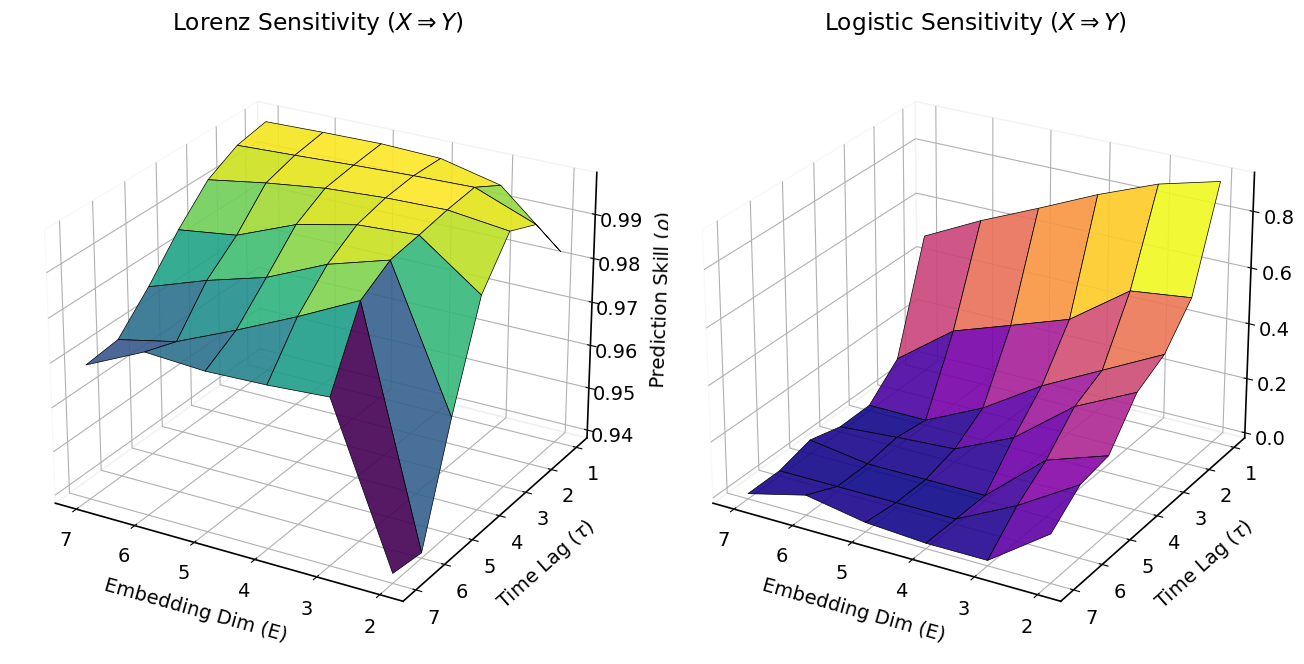

=== SENSITIVITY ANALYSIS SUMMARY STATS ===
Lorenz System (X => Y):
  - Maximum skill (rho) : 0.9982
  - Optimal Parameters  : E = 3, tau = 2

Asymmetric Logistic System (X => Y):
  - Maximum skill (rho) : 0.9164
  - Optimal Parameters  : E = 2, tau = 1


In [6]:
# SENSITIVITY ANALYSIS & STATS

# Define grid for parameters
E_grid = np.arange(2, 8)
tau_grid = np.arange(1, 8)
E_mesh, Tau_mesh = np.meshgrid(E_grid, tau_grid)

Z_lor = np.zeros_like(E_mesh, dtype=float)
Z_asy = np.zeros_like(E_mesh, dtype=float)

# Compute matrices (L=600)
for i in range(len(tau_grid)):
    for j in range(len(E_grid)):
        Z_lor[i, j] = ccm(L_X, L_Y, E=E_grid[j], tau=tau_grid[i], L=600) # Lorenz X=>Y
        Z_asy[i, j] = ccm(A_X, A_Y, E=E_grid[j], tau=tau_grid[i], L=600) # Logistic X=>Y


# Generate 3D Surface Plots
fig_sens = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 2, wspace=-0.05, left=0.05, right=0.95) 

ax_s1 = fig_sens.add_subplot(gs[0, 0], projection='3d')
surf1 = ax_s1.plot_surface(E_mesh, Tau_mesh, Z_lor, cmap='viridis', edgecolor='k', lw=0.5, alpha=0.9)
ax_s1.set_xlabel("Embedding Dim (E)", labelpad=10)
ax_s1.set_ylabel(r"Time Lag ($\tau$)", labelpad=10)
ax_s1.set_zlabel(r"Prediction Skill ($\rho$)", labelpad=10)
ax_s1.set_title(r"Lorenz Sensitivity ($X \Rightarrow Y$)")
ax_s1.view_init(elev=25, azim=120)
ax_s1.xaxis.pane.fill = False; ax_s1.yaxis.pane.fill = False; ax_s1.zaxis.pane.fill = False
ax_s1.grid(True)

ax_s2 = fig_sens.add_subplot(gs[0, 1], projection='3d')
surf2 = ax_s2.plot_surface(E_mesh, Tau_mesh, Z_asy, cmap='plasma', edgecolor='k', lw=0.5, alpha=0.9)
ax_s2.set_xlabel("Embedding Dim (E)", labelpad=10)
ax_s2.set_ylabel(r"Time Lag ($\tau$)", labelpad=10)
ax_s2.set_zlabel(r"Prediction Skill ($\rho$)", labelpad=10)
ax_s2.set_title(r"Logistic Sensitivity ($X \Rightarrow Y$)")
ax_s2.view_init(elev=25, azim=120)
ax_s2.xaxis.pane.fill = False; ax_s2.yaxis.pane.fill = False; ax_s2.zaxis.pane.fill = False
ax_s2.grid(True)

plt.show()

# Print Summary Stats
print("=== SENSITIVITY ANALYSIS SUMMARY STATS ===")
# Lorenz Stats
max_idx_lor = np.unravel_index(np.argmax(Z_lor), Z_lor.shape)
opt_tau_lor, opt_E_lor = tau_grid[max_idx_lor[0]], E_grid[max_idx_lor[1]]
print(f"Lorenz System (X => Y):")
print(f"  - Maximum skill (rho) : {Z_lor.max():.4f}")
print(f"  - Optimal Parameters  : E = {opt_E_lor}, tau = {opt_tau_lor}")

# Asymmetric Stats
max_idx_asy = np.unravel_index(np.argmax(Z_asy), Z_asy.shape)
opt_tau_asy, opt_E_asy = tau_grid[max_idx_asy[0]], E_grid[max_idx_asy[1]]
print(f"\nAsymmetric Logistic System (X => Y):")
print(f"  - Maximum skill (rho) : {Z_asy.max():.4f}")
print(f"  - Optimal Parameters  : E = {opt_E_asy}, tau = {opt_tau_asy}")

---

####  Failure Case (Symmetry)

Takens' Theorem requires a 1:1 mapping (diffeomorphism) between the true attractor and the reconstructed shadow manifold. We intentionally violate this assumption by attempting to reconstruct the Lorenz system using only the $Z$ coordinate. 

Because $Z$ is symmetric with respect to the two "butterfly" lobes of the $X$ and $Y$ dimensions, the shadow manifold $M_Z$ collapses into a single lobe. The algorithm cannot distinguish which side of the attractor the current state is on, resulting in a failure to accurately cross-map and predict $X$.

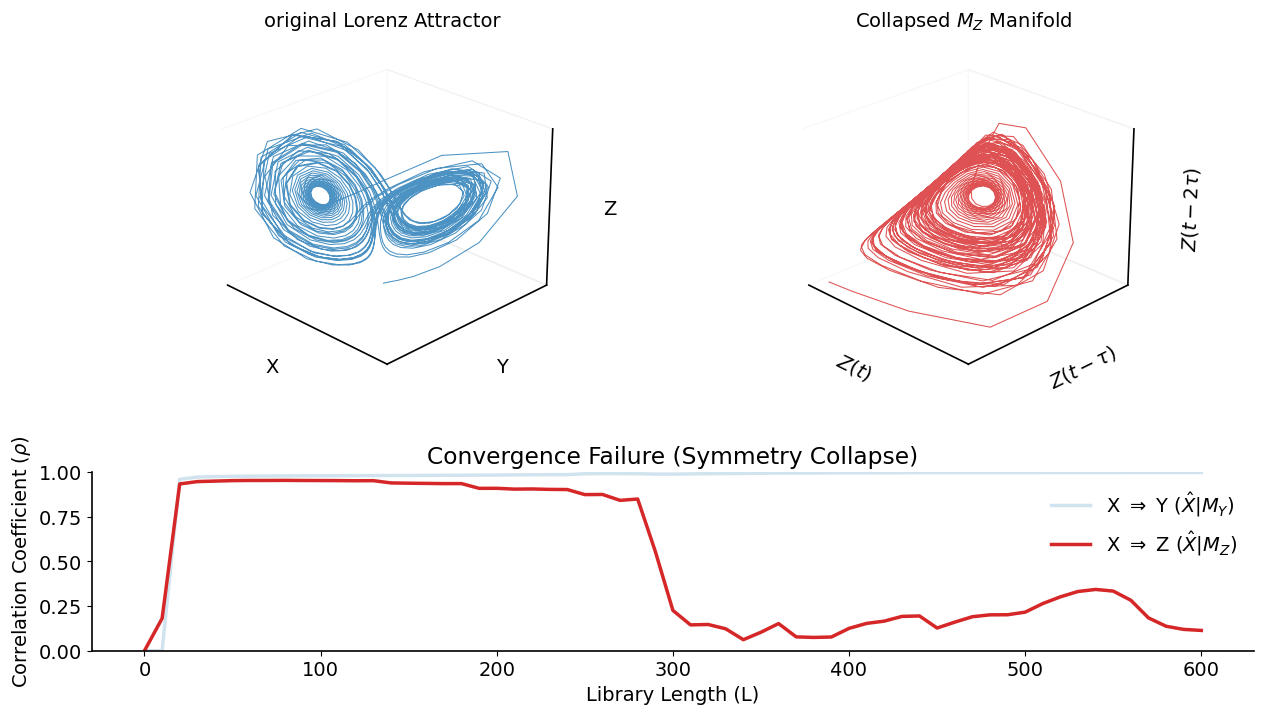

In [7]:
# FAILURE CASE 

# 1. Calculate Convergence of X => Z (Using M_Z to predict X)
rho_XZ_lor = test_convergence(L_X, L_Z, E=3, tau=2, L_range=L_range)


fig_fail = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0) 

# Top Left: Lorenz Attractor
ax_f1 = fig_fail.add_subplot(gs[0, 0], projection='3d')
ax_f1.plot(L_X[:1000], L_Y[:1000], L_Z[:1000], lw=0.75, color='#1f77b4', alpha=0.8)
ax_f1.set_xlabel("X"); ax_f1.set_ylabel("Y"); ax_f1.set_zlabel("Z")
ax_f1.set_title("original Lorenz Attractor", fontsize=14)
ax_f1.view_init(elev=25, azim=-45)

# Top Right: The Collapsed M_Z Manifold
M_Z_lor, _ = build_shadow_manifold(L_Z[:1000], E=3, tau=2)
ax_f2 = fig_fail.add_subplot(gs[0, 1], projection='3d')
ax_f2.plot(M_Z_lor[:, 0], M_Z_lor[:, 1], M_Z_lor[:, 2], lw=0.75, color='#d62728', alpha=0.8)
ax_f2.set_xlabel(r'$Z(t)$'); ax_f2.set_ylabel(r'$Z(t-\tau)$'); ax_f2.set_zlabel(r'$Z(t-2\tau)$')
ax_f2.set_title("Collapsed $M_Z$ Manifold", fontsize=14)
ax_f2.view_init(elev=25, azim=-45)

for ax in [ax_f1, ax_f2]:
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# Bottom Row: Convergence Failure
ax_f3 = fig_fail.add_subplot(gs[1, :])
ax_f3.plot(L_range, rho_XY_lor, label=r'X $\Rightarrow$ Y ($\hat{X}|M_Y$)', color='#1f77b4', lw=2.5, alpha=0.2) 
ax_f3.plot(L_range, rho_XZ_lor, label=r'X $\Rightarrow$ Z ($\hat{X}|M_Z$)', color='#d62728', lw=2.5)
ax_f3.set_xlabel("Library Length (L)"); ax_f3.set_ylabel(r"Correlation Coefficient ($\rho$)")
ax_f3.set_title("Convergence Failure (Symmetry Collapse)")
ax_f3.set_ylim(0, 1)
ax_f3.legend(frameon=False)

plt.show()